In [3]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


# Kiti darbai:
# Preprocessing acds reiksmiu. Clippint min ir max kokios gali buti.

In [4]:
import optuna

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
BATCH_SIZE = 8
PATCH_SIZE = 8

In [6]:
TRIALS = 20

In [7]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
# def _get_4d_patch_tensor(patch: torch.tensor):
#     return torch.tensor(patch).\
#         unsqueeze(1)

def _get_vq_loss(recon_x: torch.tensor, x: torch.tensor, vq_loss: float) -> float:
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

def _get_bits_from_tensor(x: torch.tensor) -> float:
    return (x.element_size() * x.numel()) * 8

# def _get_compression_ratio(a: torch.tensor, b: torch.tensor, precision: int) -> float:
#     a_bits = _get_bits_from_tensor(a)
#     b_bits = _get_bits_from_tensor(b)
    
#     print(f"a BITS: {a_bits}")
#     print(f"a dtype: {a.dtype}")
    
#     print(f"b BITS: {b_bits}")
#     print(f"b dtype: {b.dtype}")
    
#     return np.round(a_bits / b_bits, precision)

def event_hits_metrics(events: PixelDigiEvent, reconstructed_events: PixelDigiEvent) -> None:
    return {
        "rmse" : compare_matching_hits(events, reconstructed_events, metric='rmse'),
        'mae': compare_matching_hits(events, reconstructed_events, metric='mae'),
        'mismatch_ratio': compare_matching_hits(events, reconstructed_events, metric='mismatch_ratio'),
        'reco_precision_recall' : compare_hit_presence(events, reconstructed_events)
    }

# Based on formula 2.2, "Comparative study of compression algorithms on time series data for IoT devices"
def _get_patch_bits(num_embeddings: int, embedding_size: int) -> float:
    bits_per_index = np.ceil(np.log2(num_embeddings))
    total_encoding_bits = embedding_size * bits_per_index
    return total_encoding_bits

def _get_compression_ratio(image: torch.tensor, num_embeddings: int, embedding_size: int) -> float:
    image_bits = _get_bits_from_tensor(image)
    result = image_bits / _get_patch_bits(num_embeddings, embedding_size)
    return result

In [8]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:06<00:00, 154.82it/s]


In [9]:
# Params
batch_size = 64
learning_rate = 1e-5
# num_epochs = 80
num_epochs = 80
channels = 1
latent_dim = 32
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.21 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2

decay = 0.98
vq_epsilon = 1e-5

LOG_EVERY = 10


In [10]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]


In [12]:
events_train_display = iter(events_train)

In [13]:
event_train_patches = event_hits_to_patches(event_train, patch_size=PATCH_SIZE)
event_train_patches_adcs = event_train_patches.as_array()
event_train_patches_adcs.shape

(15857, 64)

In [14]:
event_train_patches_adcs[0].shape

(64,)

In [15]:
len(event_train_patches_adcs)

15857

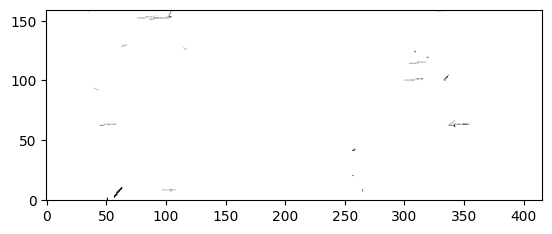

In [16]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [17]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [18]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5], std=[0.5])    
])
event_dataset = PixelPatchesDataset(event_train)

train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Data preprocessing
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [19]:
data_sample = next(iter(train_loader))
data_sample.shape

torch.Size([64, 8, 8])

In [20]:
data_sample[0].dtype

torch.uint8

In [21]:
# next(iter(train_loader))

In [22]:
# patch_tensor = _get_4d_patch_tensor(data_sample[0])
# patch_tensor.shape

In [23]:
len(train_loader)

248

In [24]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        # (1, 0, 2, 3
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                
                # controlls how smoothly the weights change
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        
        # print(quantized.shape)
        
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        # quantized = quantized.contiguous()
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encoding_indices
        )

In [25]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [26]:
# Updates
# Batch normalization reduced value shift by subtracting mean and deviding variance
# Also uses learnable parameters beta


class VQVAE(nn.Module):
    def __init__(self, hidden_channels: int, kernel_size: int, beta: float):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels * 2, kernel_size=kernel_size, stride=2),
            nn.ReLU(),
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size, stride=2),
            nn.ReLU(),
            # Residual(hidden_channels, num_residual_layers),
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1),
            nn.ReLU(),
            #  nn.BatchNorm2d(latent_dim)
        )

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            # nn.GroupNorm(num_groups=8, num_channels=16),
            nn.ReLU(),
            # nn.BatchNorm2d(latent_dim),
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=1),
            nn.ReLU(),
            # Residual(hidden_channels, num_residual_layers),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels * 2, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels * 2, channels, kernel_size=kernel_size, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        z_e = self.encoder(x)        
        
        # print(f"Compressed shape: {z_e.shape}")
        
        z_q, vq_loss, perplexity, _ = self.vq_layer(z_e)
        
        # print(z_q.shape)
        
        # bit_size = encodings.element_size() * 8
        # print(f"Calculated Codebook size: {bit_size} bits")
    
        x_recon = self.decoder(z_q)    
        
        return (
           x_recon, 
           vq_loss, 
           perplexity, 
           z_q
        )

In [35]:

def vq_vae_hyperparameter_tuning(trial) -> None:
    learning_rate = trial.suggest_float('lr', 2e-5, 1e-1)
    beta = trial.suggest_float('beta', 0.21, 0.85)
    
    model = VQVAE(
        hidden_channels = 8,
        kernel_size = 2,
        beta=beta
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(), 
        lr=learning_rate, 
        amsgrad=True
    )   
    
    avg_total_loss = 0     

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        
        for (_, X_adcs) in enumerate(train_loader):
            optimizer.zero_grad()
            X_adcs = X_adcs.to(device)
            X_adcs = X_adcs.float()
            
            
            X_adcs_tr = X_adcs.unsqueeze(1).permute(0, 1, 2, 3)
            
            (
                recon_patch, 
                vq_loss, 
                _, 
                _
            ) = model(
                X_adcs_tr
            )
            recon_patch = recon_patch.float().to(device)      
            
            loss = _get_vq_loss(recon_patch, X_adcs_tr, vq_loss)
            loss.backward()
            train_loss += loss.item()
            
            
            optimizer.step()        

            # Update tqdm description with current loss
            # scheduler.step()
            
        # Saving epoch  statistics
        # perplexity_average = perplexity_per_epoch / len(train_loader)
        
        # perplexity_values.append(perplexity_average)    
        avg_loss = train_loss / len(train_loader)
        # average_loss_values.append(avg_loss)
        # print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
        
        avg_total_loss += avg_loss
    
    return avg_total_loss
            

            

In [36]:
# vq_vae_study = optuna.create_study(direction="minimize")
vq_vae_study = optuna.create_study(direction="minimize")
vq_vae_study.optimize(
    vq_vae_hyperparameter_tuning,
    TRIALS
)
print("Best hyperparameters for VQ-VAE")

for key, value in vq_vae_study.best_params.items():
    print(f"{key} = {value}")

[I 2026-04-13 09:11:43,804] A new study created in memory with name: no-name-526249c5-4114-4f2c-acdd-d030e6fb48b2
[I 2026-04-13 09:12:14,831] Trial 0 finished with value: 45156.432318779734 and parameters: {'lr': 0.0773344920460763, 'beta': 0.49502968943267645}. Best is trial 0 with value: 45156.432318779734.
[I 2026-04-13 09:12:45,610] Trial 1 finished with value: 45156.44741452125 and parameters: {'lr': 0.013641739210578522, 'beta': 0.5734364452409406}. Best is trial 0 with value: 45156.432318779734.
[I 2026-04-13 09:13:17,769] Trial 2 finished with value: 45156.55024337769 and parameters: {'lr': 0.018672811990664537, 'beta': 0.7179190707849151}. Best is trial 0 with value: 45156.432318779734.
[I 2026-04-13 09:13:46,971] Trial 3 finished with value: 45156.664983441755 and parameters: {'lr': 0.010809789824224423, 'beta': 0.5391299676233361}. Best is trial 0 with value: 45156.432318779734.
[I 2026-04-13 09:14:15,717] Trial 4 finished with value: 45156.31633426298 and parameters: {'lr':

Best hyperparameters for VQ-VAE
lr = 0.0015857362745524675
beta = 0.40344435566698983


In [ ]:
# TODO: Try fitting all patch'es to VQ-VAE, get calculated bits of patches and total hits per event.
# TODO: Calculate ratio before how many bits were used per patch and after compression how many bits were 
# used per patch 

In [ ]:
# # Test model with unseen data
# events_test_patches_adcs = [
#     event_hits_to_patches(event, PATCH_SIZE).as_array()
#     for event in events_test[:SELECTED_EVENTS]
# ]

# events_test_patches = [
#     event_hits_to_patches(event, PATCH_SIZE)
#     for event in events_test[:SELECTED_EVENTS]
# ]
# print(f"Events test: {len(events_test_patches_adcs)}")
# print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [ ]:
# X_test_patch = events_test_patches_adcs[0][0]
# X_test = torch.tensor(X_test_patch).to(device).float()
# X_test = X_test.reshape(
#     PATCH_SIZE, 
#     PATCH_SIZE
# ).unsqueeze(1).permute(1, 0, 2).unsqueeze(1)


In [ ]:
# X_test.shape

torch.Size([1, 1, 8, 8])

In [ ]:
# model.eval()

# print("Compression quality measurements")

# with torch.no_grad():
#     model = VQVAE(
#         hidden_channels = 3,
#         kernel_size = 2    
#     ).to(device)
#     X_test = X_test.permute(1, 0, 2, 3)
#     print(X_test.shape)
#     z = model.encoder(X_test)
#     z, vq_loss, perplexity, encodings = model.vq_layer(z)
#     print(f"Latent shape: {z.shape}")
    
#     used_codes = torch.unique(encodings)
#     num_used = used_codes.numel()
    
#     print(f"Codebook unique encodings:{len(used_codes)}")
#     print(encodings.shape)
#     print(encodings.unique())
    
#     codebook = model.vq_layer._embedding.weight
#     codebook_size = codebook.element_size() * codebook.numel()
    
#     print(f"Codebook size: {len(used_codes)}")
    
#     X_test_bits = _get_bits_from_tensor(X_test)
    
#     compression_ratio = _get_compression_ratio(X_test, num_embeddings, encodings.numel())
#     print(f"Compression ratio: {compression_ratio}")
    
#     patch_bits = _get_patch_bits(num_embeddings, encodings.numel())
#     print(f"Tensor bits: {X_test_bits}")
#     print(f"Used patch bits: {patch_bits}")
    
#     # TOtal codebook size
#     print(f"Embedding size: {encodings.numel()}")
    
#     # print(encodings.shape)
    

Compression quality measurements
torch.Size([1, 1, 8, 8])
Latent shape: torch.Size([1, 32, 2, 2])
Codebook unique encodings:3
torch.Size([4, 1])
tensor([ 28,  90, 115], device='cuda:0')
Codebook size: 3
Compression ratio: 73.14285714285714
Tensor bits: 2048
Used patch bits: 28.0
Embedding size: 4


In [ ]:
# events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_3521379/2342257702.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Average reconstruction loss over epochs values over epochs


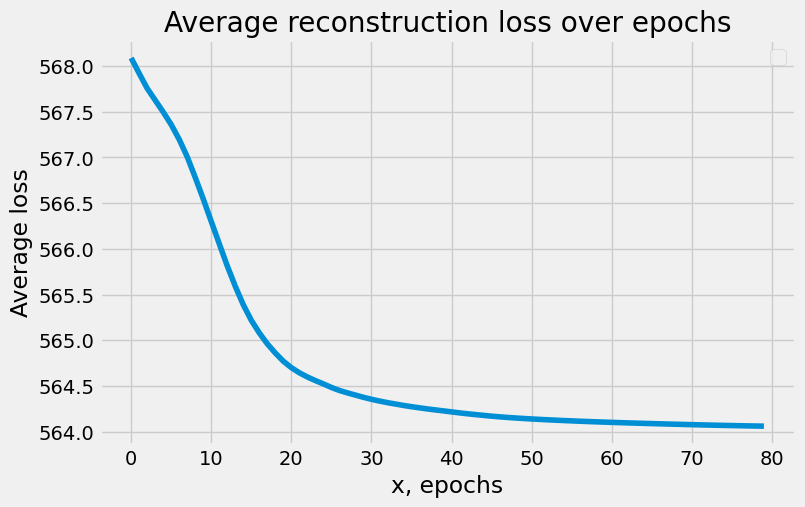

In [ ]:
# plot_metric_results(
#     average_loss_values, 
#     list(range(num_epochs)), 
#     "Average loss", 
#     "Average reconstruction loss over epochs",
#     "x, epochs"
# )

In [ ]:
# torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [ ]:
# TODO: change debug for option change event_hit_test count
# def _get_reshape_tensor(patch_flatten: np.array) -> torch.tensor:
#     patch = patch_flatten.reshape(PATCH_SIZE, PATCH_SIZE)
#     patch_tensor_ini = torch.tensor(patch)
#     # patch_tensor = patch_tensor_ini.unsqueeze(1).unsqueeze(1).transpose(0, 2)
#     patch_tensor = patch_tensor_ini.unsqueeze(1)
#     patch_tensor = patch_tensor.float()
#     patch_tensor = patch_tensor.to(device)
#     return patch_tensor

# events_test_patches_tensors = []
# for event_test_patches_adcs in events_test_patches_adcs:
#     event_test_patches_tensors = list(map(_get_reshape_tensor, event_test_patches_adcs))
#     event_test_patch_first = event_test_patches_tensors[0]
#     print(f"DEBUG: first event shape: {event_test_patch_first.shape}")
    
#     events_test_patches_tensors.append(event_test_patches_tensors)

In [ ]:
# len(event_test_patches_tensors)

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)


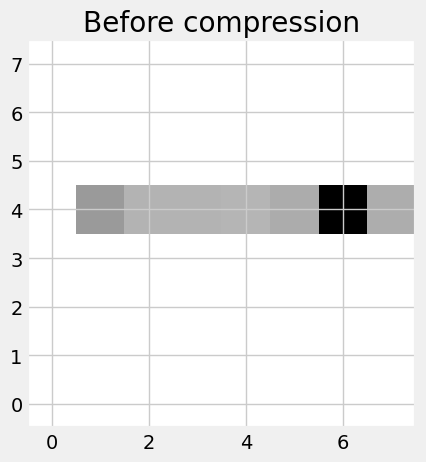

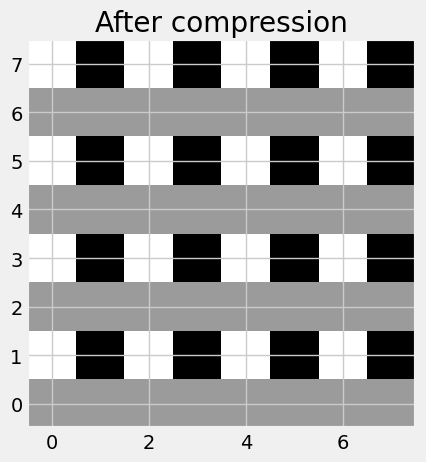

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)


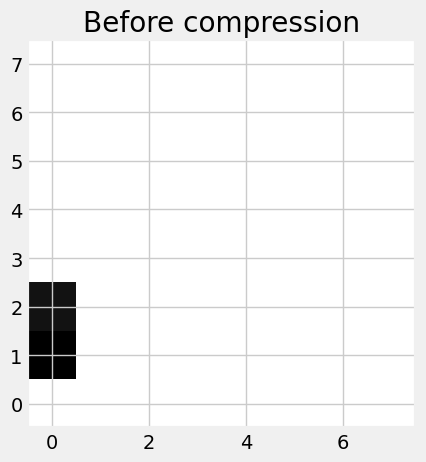

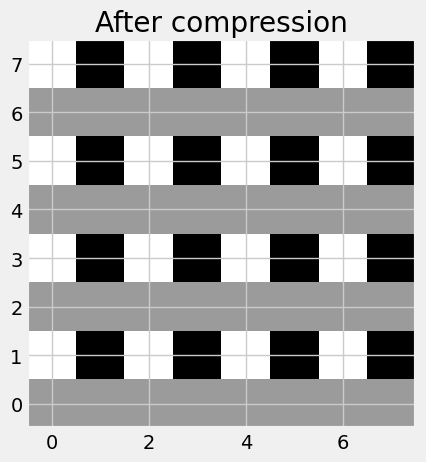

Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (64, 8, 8)
Patch comp

In [ ]:
# # Performing test on unseen data
# plot_patches_debug = 2
# plotted_patches = 0
# fill_value = 0
# decompressed_events = []
# T_SIMILAR = 0.7
# T_DISSIMILAR = 0
# T_IDENTICAL = 0.9
# T_CODEBOOK = 2

# # model.load_state_dict(torch.load("vq_vae_pileup.pth"))
# model = model.to(device)
# # model.eval() 

# # compressing patches
# events_test_patches = [
#     event_hits_to_patches(event, PATCH_SIZE)
#     for event in events_test
# ]

# # compressing / decompressing each event patch adcs
# for (i, event_test_loader) in enumerate(events_test_loaders):
#     event_adcs_merged = []
    
#     for (j, event_patch) in enumerate(event_test_loader):
#         with torch.no_grad():
#             event_patch = event_patch.to(device)
#             (
#                 recon_patch, 
#                 _, 
#                 _, 
#                 z_q
#             ) = model(event_patch)
            
#             # Reconstructed adcs
#             patch_original = _tensor_to_numpy(
#                 event_patch.squeeze(1)
#             )
            
#             recon_patch_np = _tensor_to_numpy(
#                 recon_patch.squeeze(1)
#             )
            
#             # compression_ratio = _get_compression_ratio(
#             #     a=event_patch,
#             #     b=z_q,
#             #     precision=10
#             # )
            
#             print("Patch compression statistics")
#             print(f"Before: {event_patch.shape}")
#             print("After compression")
#             print(f"After: {recon_patch_np.shape}")            
#             # print(f"Event Patch {j + 1} compression ratio (original/q_latent): {compression_ratio}")
            
#             if plotted_patches < plot_patches_debug:
#                 plot_patch(patch_original[0], "Before compression")        
#                 plot_patch(recon_patch_np[0], "After compression")
#                 plotted_patches += 1
            
#             # compression_ratio_values.append(compression_ratio)
            
#             adcs_decoded = recon_patch_np.flatten()
#             event_adcs_merged.append(adcs_decoded)
    
#     # saving new decompressed
#     # checking occupancy
#     X_patches = np.concatenate(event_adcs_merged)
#     X_occupancy = (X_patches != fill_value)
    
#     event_test_patches = events_test_patches[i]
    
#     # # Make the first decompressed event
#     event_patches_decompressed = PixelEventPatches(
#         detector=pix_det,
#         patch_size=PATCH_SIZE,
#         event_id=event_test_patches.event_id,
#         det_ids=event_test_patches.det_ids,
#         rows=event_test_patches.rows,
#         cols=event_test_patches.cols,
#         adcs=X_patches,
#         occupancy=X_occupancy
#     )
#     event_hits = event_patches_to_hits(
#         event_patches_decompressed
#     )
#     decompressed_events.append(event_hits)
    
#     print(f"Showing event_id = {event_hits.id_} statistics")
    
#     event_codebooks_high = sum([perplexity > T_CODEBOOK for perplexity in perplexity_values])
#     event_codebooks_low = sum([perplexity < T_CODEBOOK for perplexity in perplexity_values])
    
#     print("-----------")
#     print(f"Above limit: {T_CODEBOOK}, codebook count: {event_codebooks_high}")
#     print(f"Lower limit: {T_CODEBOOK}, codebook count: {event_codebooks_low}")
    
#     print(f"Showing decompressed vs original patches ssim:")
    
#     identical_count = sum(list(map(lambda x: x > T_IDENTICAL, ssim_values)))
#     similar_count = sum(list(map(lambda x: x > T_SIMILAR and x < T_IDENTICAL, ssim_values)))
#     dissimilar_count = sum(list(map(lambda x: x < T_DISSIMILAR, ssim_values)))
    
#     print("-----------")
#     print(f"Identical patches: {identical_count}")
#     print(f"Similar patches: {similar_count}")
#     print(f"Dissimilar patches: {dissimilar_count}")
#     print("-----------")  

Event test before compression


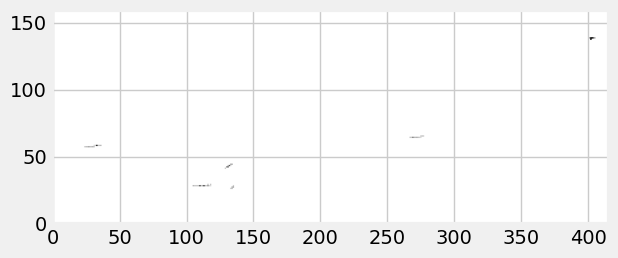

In [ ]:
# print("Event test before compression")
# for event_test in events_test[:SELECTED_EVENTS]:
#     show_image(event_test)

Event test after compression


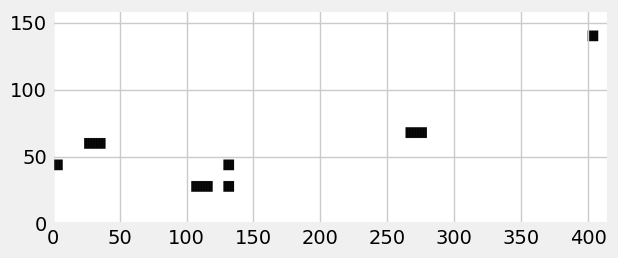

In [ ]:
# print("Event test after compression")
# for event_test in decompressed_events[:SELECTED_EVENTS]:
#     show_image(event_test)

<h2>Event compression statistics<h2>

In [ ]:
# # hit count in original events
# n_hits_total = 0
# for event_test in events_test[:SELECTED_EVENTS]:
#     print(np.unique(event_test.det_ids))
#     n_hits_total += len(event_test)
    
# print(f"Selected events have hits: {n_hits_total}")

[303042564 303042568 303042572 ... 353335300 353338372 353339396]
Selected events have hits: 24791


In [ ]:
# # hit count in original events
# n_hits_total_vq = 0
# for decomp_event_test in decompressed_events[:SELECTED_EVENTS]:
#     # print(np.unique(decomp_event_test.det_ids))
#     # print([len(hit) for hit in decomp_event_test.hits])
#     n_hits_total_vq += len(decomp_event_test)
    
# print(f"Decompressed events have hits: {n_hits_total_vq}")

Decompressed events have hits: 540928


In [ ]:
# events_test[0].hits[0].adcs

array([153,  47,  65,  66,  92,  64,  67,  80,  55,  38,  55, 236,  58,
        59,  70,  75,  56,  56,  55,  62, 189,  61,  85, 192,  67,  51,
       106,  54,  42,  39,  58,  59, 111, 156,  51, 169,  49,  41,  82,
        70,  71,  86,  89,  51,  58,  58, 126,  74,  69,  80,  63,  52,
        38,  48,  60,  53, 106, 255, 255, 255, 182,  81], dtype=uint8)

In [ ]:
# decompressed_events[0].hits[0].adcs

array([0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.43988353,
       0.4668678 , 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.43988353,
       0.4668678 , 0.43988353, 0.4668678 , 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.43988353,
       0.4668678 , 0.43988353, 0.4668678 , 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.4504451 , 0.45049056, 0.4504451 ,
       0.45049056, 0.43988353, 0.4668678 , 0.43988353, 0.4668678 ,
       0.43988353, 0.4668678 , 0.43988353, 0.4668678 , 0.4504451 ,
       0.45049056, 0.4504451 , 0.45049056, 0.4504451 , 0.45049056,
       0.4504451 , 0.45049056, 0.43988353, 0.4668678 , 0.43988

<h1>VQ-VAE compression metrics</h1>

In [ ]:
# # for i in range(SELECTED_EVENTS):
# #     event = events_test[i]
# #     result = 
# #         event,
# #         decompressed_events[i]
# #     )
# #     print(f"Event ID = {event.id_}")
# #     print(result)

# # Showing test vs reconstructed events
# event_hits_metrics(
#    events_test[:SELECTED_EVENTS],
#    decompressed_events[:SELECTED_EVENTS] 
# )

{'rmse': 111.99507784245475,
 'mae': 93.72039031982422,
 'mismatch_ratio': 1.0,
 'reco_precision_recall': (0.04583049869853289, 1.0)}

Average Perplexity (code books per epochs) values over epochs


/tmp/ipykernel_3521379/2342257702.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


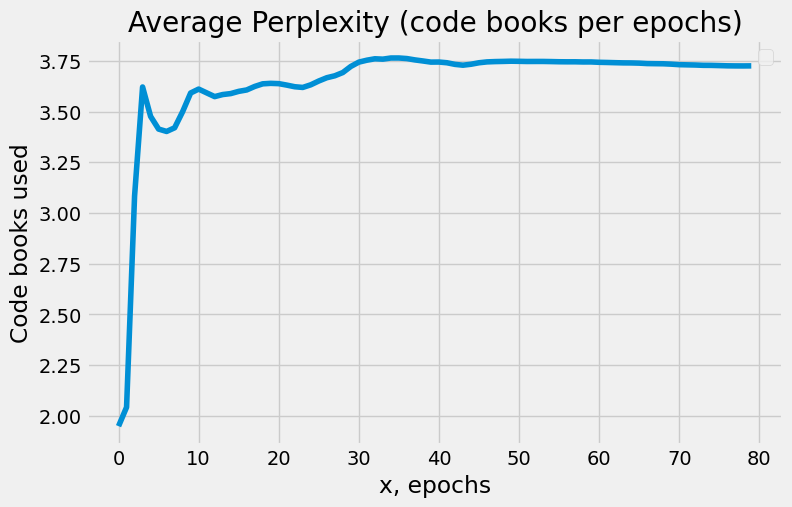

In [ ]:
# # perplexity
# plot_metric_results(
#     perplexity_values, 
#     list(range(num_epochs)), 
#     "Code books used", 
#     "Average Perplexity (code books per epochs)",
#     "x, epochs"
# )